In [13]:
import numpy as np
from matplotlib import pyplot as plt
from helper_functions.helper_data_generator import *

In [ ]:
H, W = 512, 512

radii = np.arange(2,25)   # smoother distribution 
depths = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]

num_masks = 10

masks = []
all_defects = []
counts = []

for i in range(num_masks):

    mask = generate_mask_with_spacing(
        H, W,
        radii=radii,
        depths=depths,
        N_circles=20,
        border_margin=30,
        spacing_margin=15
    )

    defects = mask_to_defect_list(mask)

    masks.append(mask)
    all_defects.extend(defects)
    counts.append(len(defects))

plot_depth_histogram(masks)

In [ ]:
plot_dataset_histogram(masks, bins=80)

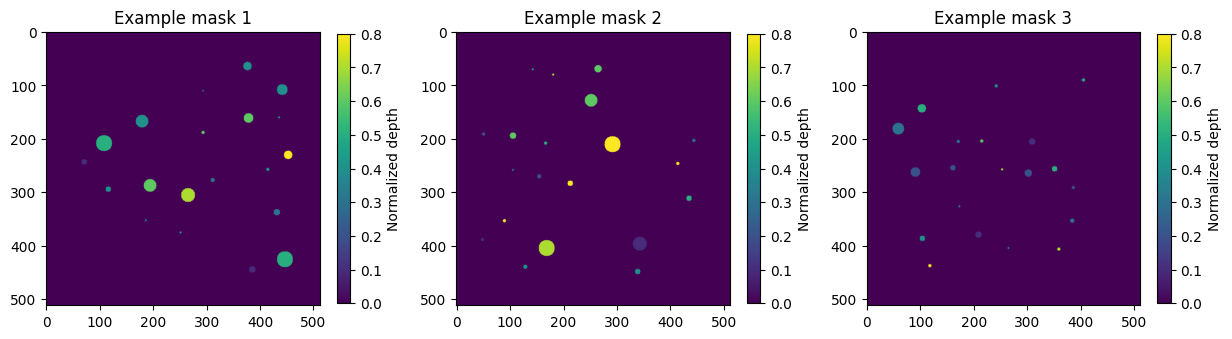

In [21]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
plt.imshow(masks[0])
plt.title('Example mask 1')
plt.colorbar(label='Normalized depth',shrink=0.5)

plt.subplot(1,3,2)
plt.imshow(masks[1])
plt.title('Example mask 2')
plt.colorbar(label='Normalized depth',shrink=0.5)

plt.subplot(1,3,3)
plt.imshow(masks[2])
plt.title('Example mask 3')
plt.colorbar(label='Normalized depth',shrink=0.5)


In [ ]:
# convert masks to array
masks = np.stack(masks, axis=0)

pos_x = np.array([d["pos_x"] for d in all_defects])
pos_y = np.array([d["pos_y"] for d in all_defects])
size  = np.array([d["size"]  for d in all_defects])
depth = np.array([d["depth"] for d in all_defects])

counts = np.array(counts)

np.savez(
    "training_dataset.npz",
    masks=masks,
    pos_x=pos_x,
    pos_y=pos_y,
    size=size,
    depth=depth,
    counts=counts
)

In [ ]:
data = np.load("training_dataset.npz")

masks = data["masks"]
counts = data["counts"]

pos_x = data["pos_x"]
pos_y = data["pos_y"]
size  = data["size"]
depth = data["depth"]

# reconstruct per-mask defect lists
defect_lists = []
idx = 0

for c in counts:
    current = []
    for _ in range(c):
        current.append({
            "pos_x": float(pos_x[idx]),
            "pos_y": float(pos_y[idx]),
            "size": float(size[idx]),
            "depth": float(depth[idx]),
        })
        idx += 1
    defect_lists.append(current)